In [30]:
from alignparse import cs_tag
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


In [16]:
column_names = [
    "query_name", "query_length", "query_start", "query_end", "strand",
    "target_name", "target_length", "target_start", "target_end",
    "num_matches", "alignment_block_length", "mapping_quality",
    "mismatch_num","DP_score", "DP_aln_score", "ambiguous_num", "aln_type",
    "minimizers", "chaining", "best_chaining", "gap", "repetitive", "mutations","E"
]

In [149]:
paf_file = "../results/alignments/229E_tile13.paf"  
df = pd.read_csv(paf_file, sep='\t', names=column_names)


/tmp/ipykernel_49655/360277445.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(paf_file, sep='\t', names=column_names)


In [145]:
def prase_paf_mutations(muts):
    if 'rl' in muts:
        return 'no_muts'
    
    full_muts_cs = muts.split('cs:Z:')[1]
    if full_muts_cs == None:
        return 'no_muts'
    else:
        mutations = cs_tag.cs_to_mutation_str(full_muts_cs)
    return mutations
    

In [142]:
df['full_muts'] = df['mutations'].apply(lambda x: prase_paf_mutations(x))

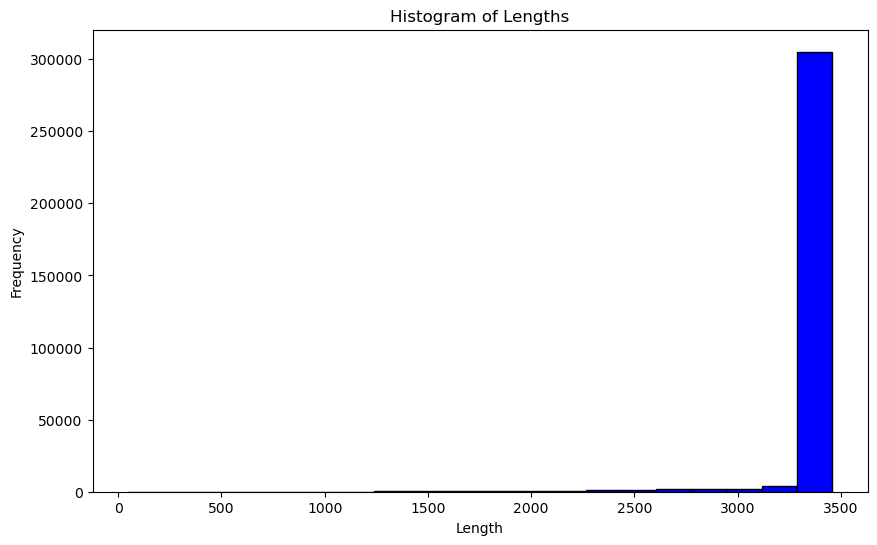

In [150]:
plt.figure(figsize=(10, 6))
plt.hist(df['num_matches'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [51]:
def read_muts(mut):
    print (mut)

In [87]:
def nucleotide_to_protein(mutations, ref_seq):
    nucleotide_changes = []
    for mut in mutations.split():
        if 'ins' not in mut and 'del' not in mut:
            try:
                ref_nt = mut[0]  
                mut_nt = mut[-1]  
                pos = int(''.join(filter(str.isdigit, mut))) - 1  
                if ref_seq[pos] == ref_nt:
                    nucleotide_changes.append((pos, mut_nt))
            except ValueError:
                continue 

    mutable_seq = list(ref_seq)
    
    for pos, mut_nt in nucleotide_changes:
        mutable_seq[pos] = mut_nt
    
    mutated_seq = "".join(mutable_seq)
    
    ref_protein = Seq(ref_seq).translate()
    mutated_protein = Seq(mutated_seq).translate()
    
    protein_muts = []
    for i, (ref_aa, mut_aa) in enumerate(zip(ref_protein, mutated_protein)):
        if ref_aa != mut_aa:
            protein_muts.append(f"{ref_aa}{i+1}{mut_aa}")
    
    return ", ".join(protein_muts)

In [91]:
ref_seq = None
with open("../data/spike.fasta") as fasta_file:  
    ref_seq = str(next(SeqIO.parse(fasta_file, "fasta")).seq)
    
df['protein_muts'] = df['full_muts'].apply(lambda x: nucleotide_to_protein(x, ref_seq))


In [94]:
def parse_protein_muts(mutations):
    parsed_muts = []
    if mutations:  
        for mut in mutations.split(', '):
            wt_aa = mut[0]  
            pos = int(mut[1:-1])  
            mut_aa = mut[-1]  
            parsed_muts.append((pos, wt_aa, mut_aa))
    return parsed_muts


all_mutations = []
for muts in df['protein_muts']:
    all_mutations.extend(parse_protein_muts(muts))

mutations_df = pd.DataFrame(all_mutations, columns=['position', 'WT', 'mutation'])


grouped_df = mutations_df.groupby(['position', 'WT'])['mutation'].apply(list).reset_index()


grouped_df.rename(columns={'mutation': 'mutations_observed'}, inplace=True)


      position WT                                 mutations_observed
0            2  F  [I, I, V, I, L, I, I, I, Y, I, L, V, Y, V, Y, ...
1            3  V  [G, D, C, D, L, L, I, I, D, D, L, D, L, I, G, ...
2            4  L  [V, M, H, M, Q, M, Q, V, R, Q, R, Q, V, M, R, ...
3            5  L  [V, R, M, R, F, V, Q, Q, Q, R, P, R, R, P, M, ...
4            6  V  [W, E, G, E, E, L, G, A, G, E, G, E, G, G, M, ...
...        ... ..                                                ...
1146      1148  S  [T, Y, T, Y, T, T, Y, T, A, A, T, A, T, A, T, ...
1147      1149  S  [T, A, T, *, P, P, A, R, T, L, L, *, A, *, *, ...
1148      1150  I  [N, N, V, M, M, S, F, T, F, M, M, M, M, M, M, ...
1149      1151  R  [Q, Q, Q, Q, L, A, A, A, A, P, L, A, A, L, L, ...
1150      1152  *  [C, G, G, R, S, R, L, C, W, C, G, R, C, S, C, ...

[1151 rows x 3 columns]


In [96]:
grouped_df['muts_num'] = grouped_df['mutations_observed'].apply(lambda x: len(x))

In [101]:
df_spike = df[df['num_matches'] > 3200]

In [102]:
df_spike

,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,ambiguous_num,aln_type,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,protein_muts
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,nn:i:0,tp:A:P,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,F74G
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,nn:i:0,tp:A:P,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,nn:i:0,tp:A:P,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,H26V
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,nn:i:0,tp:A:P,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,S50G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443531,m64272e_240829_202542/180554471/ccs/fwd,3500,0,3457,+,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:629,s1:i:3429,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::242*ca:1*gc:2004-g:1208,C243A G245C del2250to2250,C81*
443532,m64272e_240829_202542/180554471/ccs/rev,3503,43,3503,-,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:626,s1:i:3416,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::39*ct:46*at:1*tc:463+c:1617+c:1289,C40T A87T T89C ins553C ins2170C,
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,nn:i:0,tp:A:P,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,nn:i:0,tp:A:P,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,"G21C, T363N, G364R"


In [138]:
df_spike['protein_muts_num'] = df_spike['protein_muts_list'].apply(lambda x: len(x))

/tmp/ipykernel_49655/202647137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spike['protein_muts_num'] = df_spike['protein_muts_list'].apply(lambda x: len(x))


In [109]:
df_spike['protein_muts_list']= df_spike['protein_muts'].apply(lambda x: x.split(', '))

/tmp/ipykernel_49655/1198758670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spike['protein_muts_list']= df_spike['protein_muts'].apply(lambda x: x.split(', '))


,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,protein_muts,protein_muts_num,protein_muts_list
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,F74G,1,[F74G]
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,,1,[]
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,,1,[]
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,H26V,1,[H26V]
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,S50G,1,[S50G]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443531,m64272e_240829_202542/180554471/ccs/fwd,3500,0,3457,+,229E_spike,3459,1,3459,3455,...,cm:i:629,s1:i:3429,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::242*ca:1*gc:2004-g:1208,C243A G245C del2250to2250,C81*,1,[C81*]
443532,m64272e_240829_202542/180554471/ccs/rev,3503,43,3503,-,229E_spike,3459,1,3459,3455,...,cm:i:626,s1:i:3416,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::39*ct:46*at:1*tc:463+c:1617+c:1289,C40T A87T T89C ins553C ins2170C,,1,[]
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,,1,[]
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,"G21C, T363N, G364R",3,"[G21C, T363N, G364R]"


In [121]:
mutation_counts = df_spike['protein_muts_num'].value_counts().sort_index()

In [132]:
df_spike

,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,protein_muts,protein_muts_num,protein_muts_list
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,F74G,1,[F74G]
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,,1,[]
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,,1,[]
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,H26V,1,[H26V]
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,S50G,1,[S50G]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443531,m64272e_240829_202542/180554471/ccs/fwd,3500,0,3457,+,229E_spike,3459,1,3459,3455,...,cm:i:629,s1:i:3429,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::242*ca:1*gc:2004-g:1208,C243A G245C del2250to2250,C81*,1,[C81*]
443532,m64272e_240829_202542/180554471/ccs/rev,3503,43,3503,-,229E_spike,3459,1,3459,3455,...,cm:i:626,s1:i:3416,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::39*ct:46*at:1*tc:463+c:1617+c:1289,C40T A87T T89C ins553C ins2170C,,1,[]
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,,1,[]
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,"G21C, T363N, G364R",3,"[G21C, T363N, G364R]"


In [133]:
filtered_df = df_spike[df_spike['protein_muts_num'] <= 6]
mutation_counts = filtered_df['protein_muts_num'].value_counts().sort_index()
all_mutation_counts = pd.Series(index=range(0, 7), data=0)  # Create a Series for mutation counts from 0 to 6
mutation_counts = all_mutation_counts.add(mutation_counts, fill_value=0)

In [134]:
mutation_counts

0         0.0
1    380139.0
2     37502.0
3      6310.0
4      2111.0
5       996.0
6       477.0
dtype: float64

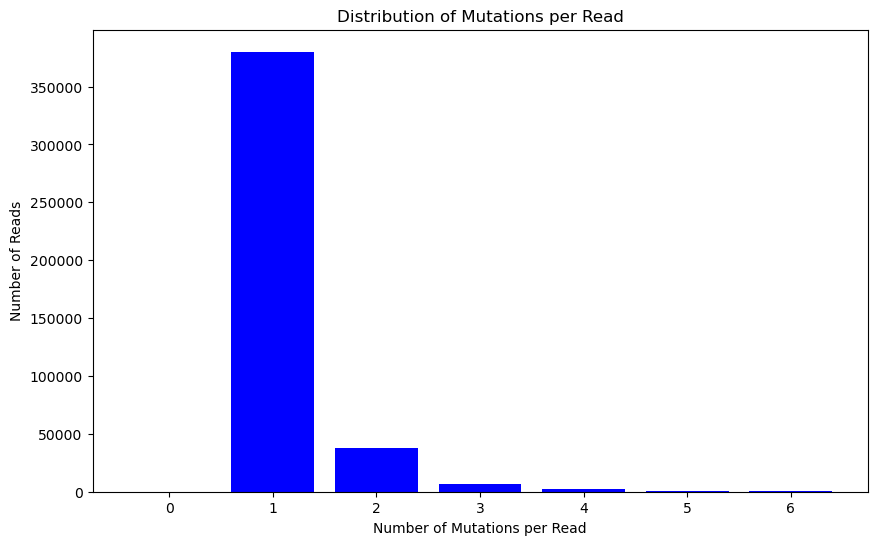

In [135]:
plt.figure(figsize=(10, 6))
plt.bar(mutation_counts.index, mutation_counts.values, color='blue')
plt.xlabel('Number of Mutations per Read')
plt.ylabel('Number of Reads')
plt.title('Distribution of Mutations per Read')
plt.xticks(mutation_counts.index)  # Ensure x-axis labels are integers
plt.show()

In [7]:
from Bio import SeqIO
from Bio.Seq import Seq
import pandas as pd

# Load your FASTA file
fasta_path = '../data/spike.fasta'
record = SeqIO.read(fasta_path, "fasta")
dna_sequence = record.seq

# Translate DNA to protein starting from protein position 18
# Protein position 18 corresponds to nucleotide position 18*3-2 in the DNA sequence
protein_start_position = 18
start_codon_position = (protein_start_position - 1) * 3
protein_sequence = dna_sequence[start_codon_position:].translate()

# Create a list of all possible amino acids (excluding wild type)
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Include the stop codon ('*')

# Initialize lists to store sequential site and amino acids
sequential_site = []
amino_acid_list = []

# Specify positions where '*' (stop codon) should be added
stop_codon_positions = [19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 571, 573, 575, 577, 579, 581, 583, 585, 587, 589, 591, 593, 595, 597, 599, 601, 603, 605, 607,609]

# Iterate over the protein sequence and populate the lists
for i, wt_aa in enumerate(protein_sequence, start=protein_start_position):
    for aa in amino_acids:
        if aa != wt_aa:
            sequential_site.append(i)
            amino_acid_list.append(aa)
    # Add stop codon if the position is in the list
    if i in stop_codon_positions:
        sequential_site.append(i)
        amino_acid_list.append('*')

# Create the DataFrame
df = pd.DataFrame({
    'sequential_site': sequential_site,
    'amino_acid': amino_acid_list
})


In [8]:
df['mutation_type'] = "designed mutation"

In [9]:
output_csv_path = '../check-library-quality/data/mutation_design_classification.csv'
df.to_csv(output_csv_path, index=False)


In [10]:

# Load your FASTA file
fasta_path = '../data/spike.fasta'  # Replace with your actual file path
record = SeqIO.read(fasta_path, "fasta")
dna_sequence = record.seq

# Translate DNA to protein starting from protein position 1 (full sequence for wild-type reference)
protein_sequence = dna_sequence.translate()

# Define the regions
regions = {
    (1, 93): 1, (94, 180): 2, (181, 267): 3, (268, 360): 4,
    (361, 441): 5, (442, 528): 6, (529, 615): 7, (616, 702): 8,
    (703, 789): 9, (790, 876): 10, (877, 963): 11, (964, 1050): 12,
    (1051, 1137): 13
}

# Initialize lists to store the columns
wildtype = []
sequential_site = []
reference_site = []
region_list = []

# Iterate over the protein sequence
for i, aa in enumerate(protein_sequence, start=1):
    wildtype.append(aa)
    sequential_site.append(i)
    reference_site.append(i)
    
    # Determine the region for this position
    region = next((region_id for (start, end), region_id in regions.items() if start <= i <= end), None)
    region_list.append(region)

# Create the DataFrame
df = pd.DataFrame({
    'wildtype': wildtype,
    'sequential_site': sequential_site,
    'reference_site': reference_site,
    'region': region_list
})



In [11]:
df

,wildtype,sequential_site,reference_site,region
0,M,1,1,1.0
1,F,2,2,1.0
2,V,3,3,1.0
3,L,4,4,1.0
4,L,5,5,1.0
...,...,...,...,...
1148,S,1149,1149,NaN
1149,I,1150,1150,NaN
1150,R,1151,1151,NaN
1151,*,1152,1152,NaN


In [12]:
# Save to CSV
output_csv_path = '../check-library-quality/data/site_numbering_map.csv'
df.to_csv(output_csv_path, index=False)

